# Dataset Preparation

This notebook validates and inspects the CSV dataset used by the intent classifier. It checks schema compatibility with `model_config.yaml`, summarizes label distributions, and creates train/validation/test split IDs.

In [1]:
import sys
from pathlib import Path

import pandas as pd

from intent_classifier.dataset import (
    RequestDataset,
    compute_label_distributions,
    split_ids,
    validate_dataset_frame,
)
from intent_classifier.settings import load_model_config, load_train_config

pd.set_option("display.max_columns", 80)

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MODEL_CONFIG_PATH = PROJECT_ROOT / "intent_classifier/config/model_config.yaml"
TRAIN_CONFIG_PATH = PROJECT_ROOT / "intent_classifier/config/train_config.yaml"

model_config = load_model_config(MODEL_CONFIG_PATH)
train_config = load_train_config(TRAIN_CONFIG_PATH)
dataset_path = PROJECT_ROOT / train_config.dataset_csv

In [3]:
model_config.head_names, dataset_path

(('business', 'undesired'),
 PosixPath('/Users/mxagar/nexo/git_repositories/intent-classifier/dataset/example_dataset.csv'))

In [4]:
df = pd.read_csv(dataset_path)
df.head()

,id,text,origin,domain,business__create_budget,business__create_invoice,business__schedule_visit,business__cancel_visit,business__modify_visit,business__send_document,business__add_customer,business__update_customer,business__ask_price,business__ask_status,undesired__prompt_injection,undesired__abuse,undesired__spam,undesired__fraud_attempt,undesired__unsafe_data_request,undesired__unsupported_request,undesired__irrelevant_request,undesired__ambiguous_request
0,sample_0001,hazme un presupuesto para cambiar el cuadro el...,synthetic,electricista,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,sample_0002,necesito una factura de la reparacion de ayer,synthetic,fontanero,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,sample_0003,agenda una visita para revisar los enchufes ma...,synthetic,electricista,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,sample_0004,cancela la visita que tenia esta tarde,synthetic,general,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,sample_0005,cambia la cita del martes al jueves,synthetic,carpintero,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print("Configured label columns:", len(model_config.label_columns))

missing_columns = sorted(set(model_config.label_columns) - set(df.columns))
extra_label_like_columns = sorted(
    column for column in df.columns
    if "__" in column and column not in model_config.label_columns
)

print("Missing configured label columns:", missing_columns)
print("Extra label-like columns:", extra_label_like_columns)

Rows: 100
Columns: 22
Configured label columns: 18
Missing configured label columns: []
Extra label-like columns: []


In [6]:
validated_df = validate_dataset_frame(df, model_config)
dataset = RequestDataset(validated_df, model_config)
print("Dataset is valid.")
dataset[0]

Dataset is valid.


{'id': 'sample_0001',
 'text': 'hazme un presupuesto para cambiar el cuadro electrico',
 'origin': 'synthetic',
 'domain': 'electricista',
 'labels': {'business': tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  'undesired': tensor([0., 0., 0., 0., 0., 0., 0., 0.])}}

In [7]:
distributions = compute_label_distributions(validated_df, model_config)
distributions

{'rows_total': 100,
 'origin_distribution': {'synthetic': 100},
 'domain_distribution': {'albañil': 8,
  'carpintero': 8,
  'electricista': 17,
  'fontanero': 14,
  'general': 44,
  'unknown': 9},
 'heads': {'business': {'create_budget': 14,
   'create_invoice': 13,
   'schedule_visit': 12,
   'cancel_visit': 6,
   'modify_visit': 7,
   'send_document': 13,
   'add_customer': 8,
   'update_customer': 9,
   'ask_price': 8,
   'ask_status': 10},
  'undesired': {'prompt_injection': 5,
   'abuse': 4,
   'spam': 3,
   'fraud_attempt': 4,
   'unsafe_data_request': 4,
   'unsupported_request': 3,
   'irrelevant_request': 3,
   'ambiguous_request': 3}}}

In [8]:
origin_domain = pd.crosstab(validated_df["origin"], validated_df["domain"])
origin_domain

domain,albañil,carpintero,electricista,fontanero,general,unknown
origin,,,,,,
synthetic,8,8,17,14,44,9


In [9]:
label_counts = []
for head in model_config.heads:
    for label in head.labels:
        column = f"{head.name}__{label}"
        label_counts.append(
            {
                "head": head.name,
                "label": label,
                "positives": int(validated_df[column].sum()),
                "prevalence": float(validated_df[column].mean()),
            }
        )

label_counts_df = pd.DataFrame(label_counts).sort_values(["head", "positives"], ascending=[True, False])
label_counts_df

,head,label,positives,prevalence
0,business,create_budget,14,0.14
1,business,create_invoice,13,0.13
5,business,send_document,13,0.13
2,business,schedule_visit,12,0.12
9,business,ask_status,10,0.10
7,business,update_customer,9,0.09
6,business,add_customer,8,0.08
8,business,ask_price,8,0.08
4,business,modify_visit,7,0.07
3,business,cancel_visit,6,0.06


Matplotlib is building the font cache; this may take a moment.


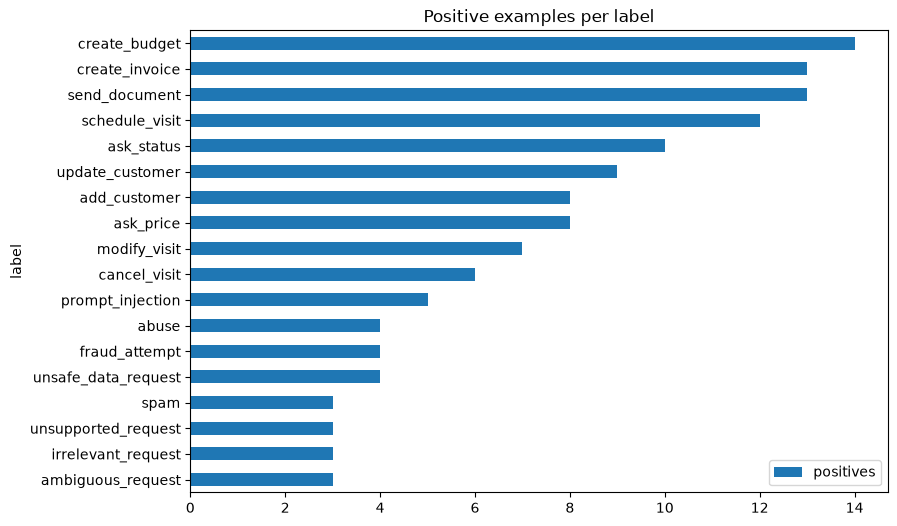

In [11]:
ax = label_counts_df.plot.barh(
    x="label",
    y="positives",
    figsize=(9, 6),
    title="Positive examples per label",
)
ax.invert_yaxis()

In [12]:
splits = split_ids(validated_df, train_config.splits, seed=train_config.seed)
split_sizes = {
    "train": len(splits.train),
    "validation": len(splits.validation),
    "test": len(splits.test),
}
split_sizes

{'train': 80, 'validation': 10, 'test': 10}

In [13]:
def split_frame(indices):
    return validated_df.iloc[indices]

split_label_summary = []
for split_name, indices in {
    "train": splits.train,
    "validation": splits.validation,
    "test": splits.test,
}.items():
    split_df = split_frame(indices)
    for head in model_config.heads:
        active_examples = (split_df[list(head.label_columns)].sum(axis=1) > 0).sum()
        split_label_summary.append(
            {
                "split": split_name,
                "head": head.name,
                "rows": len(split_df),
                "rows_with_any_label": int(active_examples),
            }
        )

pd.DataFrame(split_label_summary)

,split,head,rows,rows_with_any_label
0,train,business,80,60
1,train,undesired,80,21
2,validation,business,10,8
3,validation,undesired,10,3
4,test,business,10,9
5,test,undesired,10,2


In [14]:
# Optional prepared output. 
# The current synthetic dataset already validates cleanly.
WRITE_PREPARED_CSV = False
prepared_path = PROJECT_ROOT / "dataset/train_prepared.csv"

if WRITE_PREPARED_CSV:
    validated_df.to_csv(prepared_path, index=False)
    print(f"Wrote {prepared_path}")
else:
    print("Prepared CSV write skipped.")

Prepared CSV write skipped.
